## **Eman Khater**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pathlib import Path

import pandas as pd

data_path = Path("../datasets/president-1976-2016.csv")

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {data_path.resolve()}"
    )

Election_df = pd.read_csv(data_path)

print("Dataset shape:", election_data.shape)
election_data.head()

In [ ]:
Election_df.info()

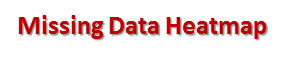

In [ ]:
sns.heatmap(Election_df.isnull(), cbar=False)

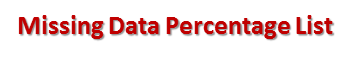

In [ ]:
percent_missing = Election_df.isnull().sum() * 100 / len(Election_df)
missing_value_df = pd.DataFrame({'column_name': Election_df.columns,
                                 'percent_missing': percent_missing})
print(round(missing_value_df ,2))

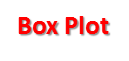

In [ ]:
Election_df.plot.box(grid='True')

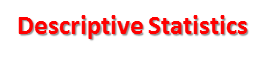

In [ ]:
print( Election_df.describe())

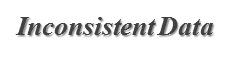

Find Inconsistent Data

In [ ]:
years = Election_df['year'].unique()
years.sort()
years

In [ ]:
states = (
    Election_df["state"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

states

In [ ]:
state_pos = (
    Election_df["state_po"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

state_pos

In [ ]:
state_fipses = (
    Election_df["state_fips"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

state_fipses

In [ ]:
state_cens = (
    Election_df["state_cen"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

state_cens

In [ ]:
state_ics = (
    Election_df["state_ic"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

state_ics

In [ ]:
offices = (
    Election_df["office"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

offices

In [ ]:
candidates = (
    Election_df["candidate"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

offices

Edit inconsistent data by :

1 - Convert everything lower case

2 -  Capitalize the first character of a string to capital (uppercase) letter

3 - Remove any white spaces at the beginning and end of cells.

4 - Remove " Charachter

5 - Remove / Charachter

In [ ]:
# convert to lower case
Election_df['candidate'] = Election_df['candidate'].str.lower()
# Capitalize the first character
Election_df['candidate'] = Election_df['candidate'].str.capitalize()
# remove trailing white spaces
Election_df['candidate'] = Election_df['candidate'].str.strip()
# remove " Charachter
Election_df['candidate'] = Election_df['candidate'].str.replace('"', '')
# remove / Charachter
Election_df['candidate'] = Election_df['candidate'].str.replace('/', ' ')

In [ ]:
candidates = Election_df['candidate'].unique()
candidates

In [ ]:
parties = Election_df['party'].unique()
parties

In [ ]:
# convert to lower case
Election_df['party'] = Election_df['party'].str.lower()
# Capitalize the first character
Election_df['party'] = Election_df['party'].str.capitalize()
# remove trailing white spaces
Election_df['party'] = Election_df['party'].str.strip()
# remove " Charachter
Election_df['party'] = Election_df['party'].str.replace('"', '')
# remove / Charachter
Election_df['party'] = Election_df['party'].str.replace('/', ' ')

In [ ]:
parties = Election_df['party'].unique()
parties

In [ ]:
writeins = Election_df['writein'].unique()
writeins.sort()
writeins

In [ ]:
candidatevotes1 = Election_df['candidatevotes'].unique()
candidatevotes1.sort()
candidatevotes1

In [ ]:
totalvotes1 = Election_df['totalvotes'].unique()
totalvotes1.sort()
totalvotes1

In [ ]:
versions = Election_df['version'].unique()
versions.sort()
versions

# **Find Outliers**

In [ ]:
numeric_columns = [
    "candidatevotes",
    "totalvotes",
]

numeric_data = Election_df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

print("First quartile:")
print(Q1)

print("\nThird quartile:")
print(Q3)

print("\nInterquartile range:")
print(IQR)

In [ ]:
print(Election_df['candidatevotes'].skew())
Election_df['candidatevotes'].describe()

# **Outliers Visualization**

The skewness value of 4.1 shows that the variable 'candidatevotes' has a right-skewed distribution

In [ ]:
plt.boxplot(Election_df["candidatevotes"])
plt.show()

In [ ]:
Election_df.candidatevotes.hist()